In [67]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "df_prepared.pkl", "rb") as f:
    df = pickle.load(f)

with open(data_path + "merged_df_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)

print("DataFrames loaded successfully:")
print(f"  df shape: {df.shape}")
print(f"  merged_df shape: {merged_df.shape}")

DataFrames loaded successfully:
  df shape: (65006, 21)
  merged_df shape: (65006, 27)


# Cluster Analysis

To conduct a clustering of the registered users, we first need to extract all session with a registered user and store these instances in a new variable

In [68]:
registered_users_df = merged_df[merged_df['isRegisteredUser'] == True].copy()

In [69]:
print(f"Total sessions in merged_df: {len(merged_df)}")
print(f"Sessions from registered users: {len(registered_users_df)}")
print(f"Unique registered users to cluster: {registered_users_df['userID'].nunique()}")

Total sessions in merged_df: 65006
Sessions from registered users: 47815
Unique registered users to cluster: 1006


In [70]:
registered_users_df['siteID'].dtype
registered_users_df['siteID_numeric'] = (registered_users_df['siteID'] == '1').astype(int)

In [71]:
# Aggregating statisitcs to User Level
user_profiles = registered_users_df.groupby('userID').agg({
    'kWhDelivered': 'mean',
    'kWhRequested': 'mean',
    'session_duration': 'mean',
    'charging_duration': 'mean',
    'sessionID': 'count',
    'hour': 'mean',
    'is_weekend': 'mean',
    'minutesAvailable': 'mean',
    'siteID_numeric': 'mean'
}).rename(columns={
    'kWhDelivered': 'avg_energy',
    'kWhRequested': 'avg_kWh_req',
    'session_duration': 'avg_duration',
    'charging_duration': 'avg_charging_duration',
    'sessionID': 'frequency',
    'hour': 'avg_start_hour',
    'is_weekend': 'pct_weekend_sessions',
    'minutesAvailable': 'avg_minutes_available',
    'siteID_numeric': 'pct_site_1'
})

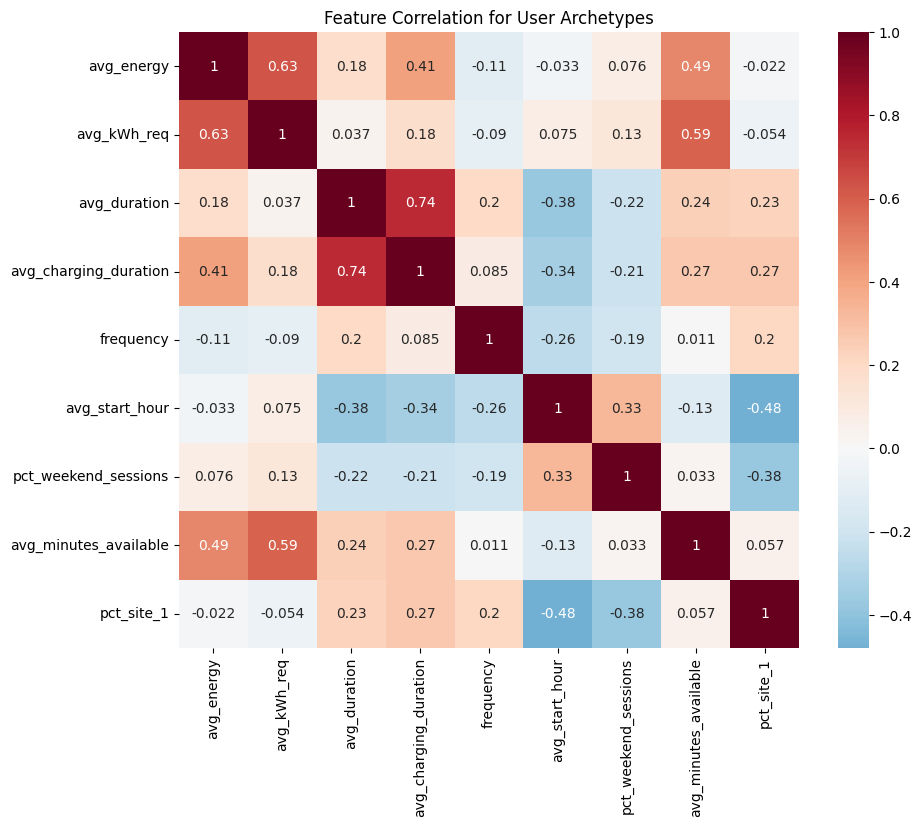

In [72]:
corr_matrix = user_profiles.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation for User Archetypes')
plt.show()

We use a correlation matrix to identify redundant features before clustering. If two features are highly correlated —such as `avg_session_duration` and `avg_charging_duration` (0.74)— including both would effectively double their weight in the distance calculation, biasing the clusters.

The matrix also reveals unexpected relationships between variables. For instance, while we would intuitively expect a strong positive correlation between `avg_duration` and `avg_energy`, they show a surprisingly low correlation of only 0.18. This suggests that stay time is not a reliable predictor of energy delivered, indicating distinct user behaviors, which we will explore further in the following analysis.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

features_to_standardize = ['avg_duration', 'avg_energy', 'pct_weekend_sessions',]
features_to_passthrough = [] # if we want to include features such as 'pct_site_1' without scaling
cluster_features = features_to_standardize + features_to_passthrough

ct = ColumnTransformer([
    ('scaled_features', StandardScaler(), features_to_standardize),
    ('passthrough_features', 'passthrough', features_to_passthrough)
])

user_profiles_scaled_array = ct.fit_transform(user_profiles)

user_profiles_scaled = pd.DataFrame(
    user_profiles_scaled_array,
    columns=cluster_features,
    index=user_profiles.index
)

We chose to limit the clustering analysis on fewer features for the following reasons:
* Including more features led to overlap between groups, making it difficult to identify distinct clusters.
* The resulting archetypes are easier to define and understand.

We chose `avg_duration` and `avg_energy` because despite the expectation that energy consumption would increase with session duration, these features showed a low correlation of only 0.18. This low correlation indicates the existence of two very different behaviors: users who treat the station primarily for parking (high duration, low energy) and those who use it for efficient charging (high energy, relatively lower duration). Our aim is to confirm these groups through clustering.

In [74]:
print(user_profiles_scaled.shape)

(1006, 3)


In [ ]:

outliers = (np.abs(user_profiles_scaled[['avg_energy', 'avg_duration', 'pct_weekend_sessions']]) > 3).any(axis=1)
print(f"Anzahl der Nutzer mit mindestens einem extremen Feature (Z > 3): {outliers.sum()}")


Anzahl der Nutzer mit mindestens einem extremen Feature (Z > 3): 24


The features `avg_duration` and `avg_energy` contain outliers that could negatively impact the clustering process. To address this we, identify and remove outliers using the 3 sigma threshold.

In [76]:
user_profiles_scaled = user_profiles_scaled[~outliers].copy()
user_profiles = user_profiles[~outliers].copy()

### Hyperparameter Tuning

c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\c

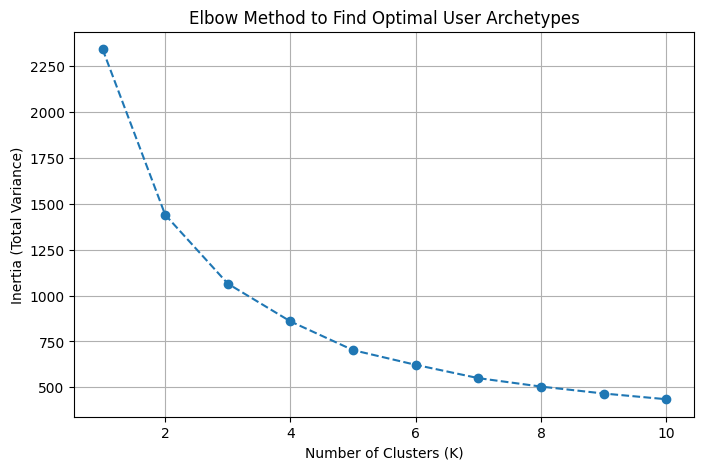

In [77]:
from sklearn.cluster import KMeans

# Calculate inertia for K=1 to K=10
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(user_profiles_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Total Variance)')
plt.title('Elbow Method to Find Optimal User Archetypes')
plt.grid(True)
plt.show()

c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\c

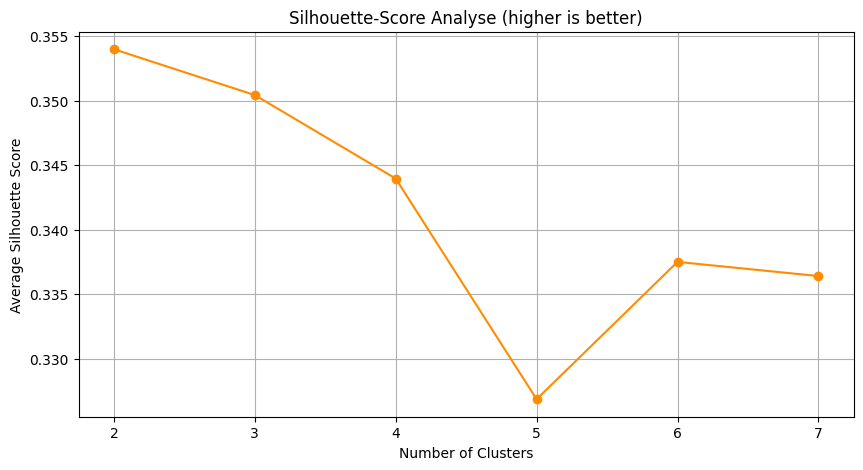

In [78]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
range_n_clusters = [2, 3, 4, 5, 6, 7]
silhouette_avgs = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(user_profiles_scaled)
    
    silhouette_avg = silhouette_score(user_profiles_scaled, cluster_labels)
    silhouette_avgs.append(silhouette_avg)
    # print(f"Für n_clusters = {n_clusters} ist der durchschnittliche Silhouette-Score: {silhouette_avg:.3f}")

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_avgs, marker='o', color='darkorange')
plt.title('Silhouette-Score Analyse (higher is better)')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()

We decided to use 4 clusters for our analysis because:
* The Silhouette analysis shows a clear peak at $k=4$ with a score of approximately 0.435. This indicates that four clusters provide the best balance between internal cohesion and separation between groups.
* In the Elbow plot, the "bend" or elbow occurs at $k=4$. Adding a fifth cluster results in significantly diminishing returns in terms of reducing the Total Variance (Inertia), suggesting that four is the "sweet spot" for capturing the data's underlying structure.

### Cluster Alg implementation

In [79]:

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4, 
    init='k-means++', 
    n_init=10, 
    random_state=42
)
kmeans.fit(user_profiles_scaled)

user_profiles['Clusters'] = kmeans.predict(user_profiles_scaled)


c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


#### I decided to choose KMeans, however this is GMM implementation.

c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\c

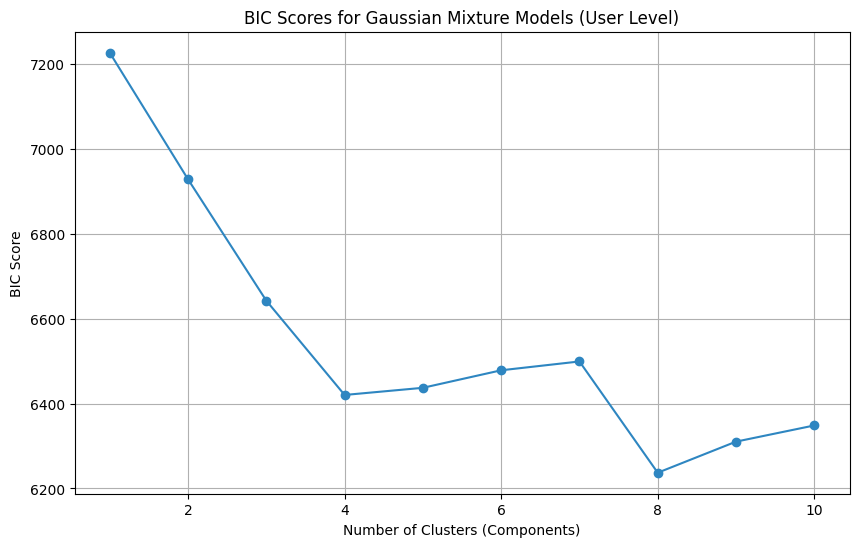

In [80]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# 1. BIC-Score Berechnung zur Bestimmung der optimalen Cluster-Anzahl
bic_scores = []
n_components_range = range(1, 11)  # Bei 1000 Usern reichen oft 1-10 Komponenten

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(user_profiles_scaled)
    bic_scores.append(gmm.bic(user_profiles_scaled))

# Plot BIC
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, marker='o', color='#2E86C1')
plt.title('BIC Scores for Gaussian Mixture Models (User Level)')
plt.xlabel('Number of Clusters (Components)')
plt.ylabel('BIC Score')
plt.grid(True)
plt.show()

In [81]:
optimal_components = 3
best_gmm = GaussianMixture(n_components=optimal_components)
best_gmm.fit(user_profiles_scaled)
user_profiles['Clusters'] = best_gmm.predict(user_profiles_scaled)

c:\Users\Daniel\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


### Clustering Results Analysis

In [82]:
cluster_mapping = {
    0: 'Cluster 1', 
    1: 'Cluster 2',
    2: 'Cluster 3',
    3: 'Cluster 4'
}
user_profiles['Clusters_Name'] = user_profiles['Clusters'].map(cluster_mapping)

cluster_summary = user_profiles.groupby('Clusters_Name')[cluster_features].mean()

print("--- ARCHETYPEN REPORT (Mean per cluster) ---")

print(cluster_summary.T) 

print("\nNumber of users per archetype:")
counts = user_profiles['Clusters_Name'].value_counts()
print(counts)

--- ARCHETYPEN REPORT (Mean per cluster) ---
Clusters_Name   Cluster 1  Cluster 2  Cluster 3
avg_duration     6.893986   2.163447   5.449166
avg_energy      10.970591   7.652432  26.455065
avg_start_hour   8.870393  13.477927  11.763785

Number of users per archetype:
Clusters_Name
Cluster 1    389
Cluster 3    302
Cluster 2    291
Name: count, dtype: int64


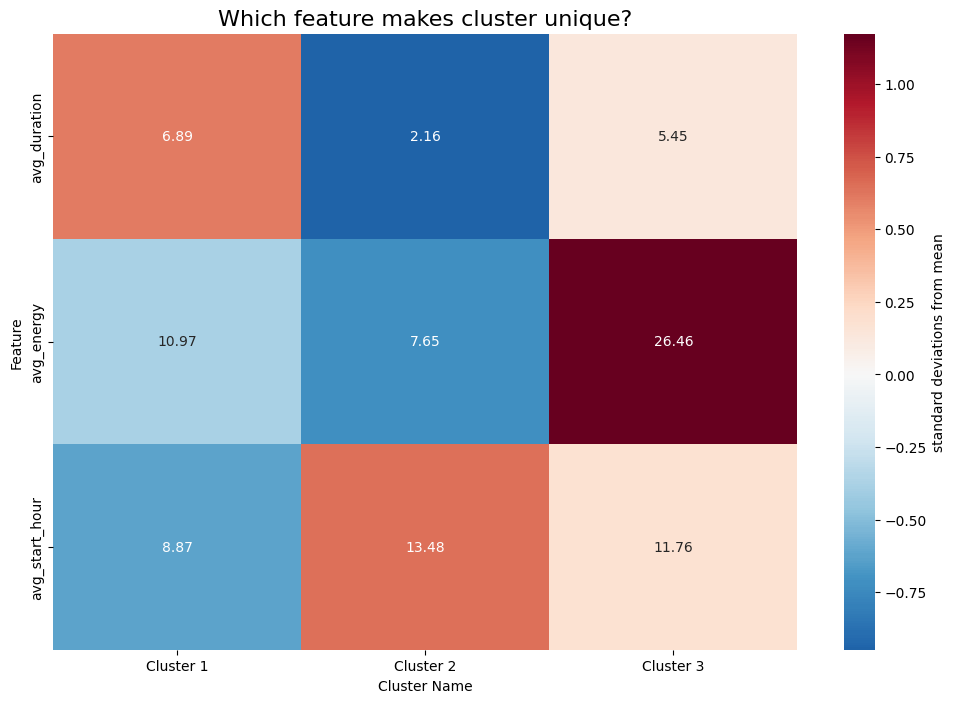

In [83]:
import seaborn as sns

cluster_summary = user_profiles.groupby('Clusters_Name')[cluster_features].mean()

# (Z-Score der Mittelwerte)
summary_scaled = (cluster_summary - user_profiles[cluster_features].mean()) / user_profiles[cluster_features].std()

plt.figure(figsize=(12, 8))
sns.heatmap(summary_scaled.T, 
            annot=cluster_summary.T,
            fmt=".2f", 
            cmap="RdBu_r", 
            center=0,
            cbar_kws={'label': 'standard deviations from mean'})

plt.title('Which feature makes cluster unique?', fontsize=16)
plt.xlabel('Cluster Name')
plt.ylabel('Feature')
plt.show()

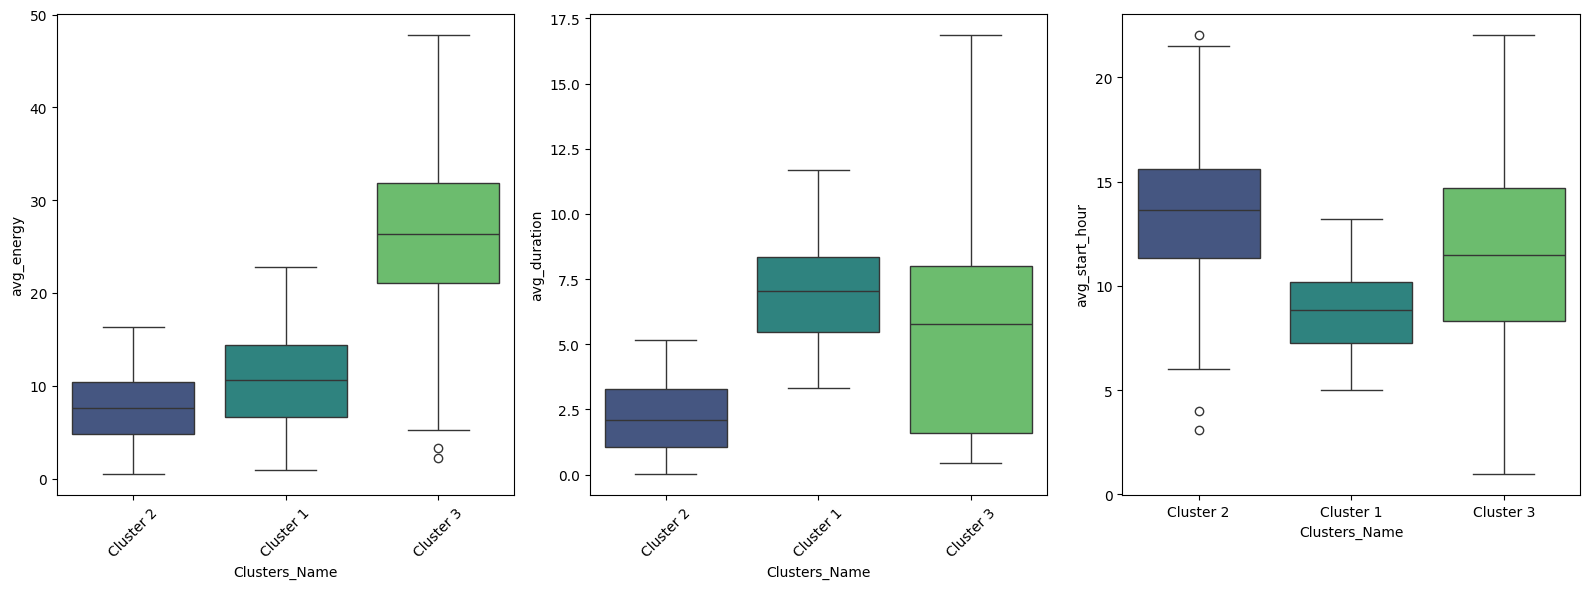

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.boxplot(x='Clusters_Name', y='avg_energy', data=user_profiles, 
            ax=axes[0], palette='viridis', hue='Clusters_Name', legend=False)

sns.boxplot(x='Clusters_Name', y='avg_duration', data=user_profiles, 
            ax=axes[1], palette='viridis', hue='Clusters_Name', legend=False)

axes[0].tick_params(axis='x', labelrotation=45)

axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

Our analysis identified four distinct user archetypes: **Low-Volume Short-Stay Users**, **Low-Volume Long-Stay Users**, **High-Volume Long-Stay Users**, and **High-Volume Short-Stay Users**. These categories allow us to add value by maximizing throughput and increasing profitability. By identifying **Low-Volume Long-Stay** users, who occupy a space while drawing very little energy, operators can implement fees or time limits to encourage turnover. This ensures spots remain available for our most profitable segment, the **High-Volume Short-Stay** Users. Because these users maximize both revenue and throughput, they are also ideal targets for marketing campaigns, such as discount cards.